# Analyzing electrophysiological properties with current steps

Uses mimopack functions to process IV protocol data recorded under current clamp.

This tutorial demonstrates how to analyze electrophysiological properties of neurons using current step protocols. The workflow covers loading and formatting raw data, isolating different phases of the voltage response, and extracting key membrane properties such as resting potential, action potential (AP) characteristics, firing rate, adaptation, passive properties (resistance and time constant), and sag. By systematically quantifying these features, the code enables characterization of neuronal excitability and intrinsic membrane properties.

Determining these electrophysiological properties is essential for understanding how neurons process synaptic drive. It is also important for quality control, and can be used to classify cells.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from mimo_pack.fileio.abf import load_abf_xr
from mimo_pack.preprocess.invitro import ivic
from mimo_pack.analysis.invitro_ephys_props import extract_iv_properties

## Load the abf file

First we need to load the .abf file that ...

In [2]:
fpath = os.path.join(*['..','test_data', 'invitro', '25707009.abf'])
data = load_abf_xr(fpath)

Then we format it for the current step protocol.

In [3]:
data = ivic(data)

## Calculating cell properties

### Isolating recording phases

First we have to separate the voltage trace into periods that are before, during, and after the current steps. To do this, we identify the voltage channel and extract the corresponding traces. We then use the protocol timing information (`stim_start`, `pulse_dur`, and `dt`) to slice the data into three segments: pre-stimulus (`v_pre`), during stimulus (`v_dur`), and rebound (`v_reb`). Each segment is plotted in a separate subplot to visualize the voltage response across these phases.

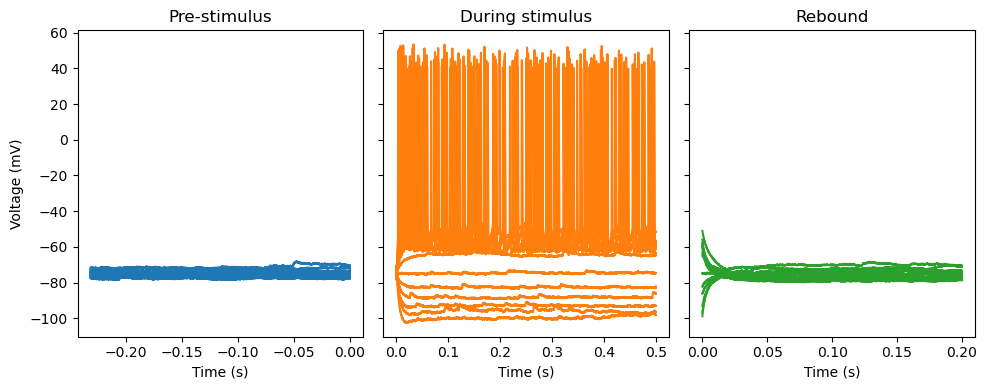

In [4]:
# Identify voltage recording
v_ch = int(np.where(data.ch_units.values == 'mV')[0][0])
v_traces = data.sel(channel=v_ch)

# Identify current steps
stim_start = 0
dt = 1.0 / float(data.attrs['sample_rate'])
pulse_dur = float(data.attrs['step_dur'])
stim_stop = stim_start + pulse_dur
pulse_vals = data.inj_current.values

# Extract pulse values
v_pre = v_traces.sel(time=slice(None, 0)).to_numpy()
v_dur = v_traces.sel(time=slice(0, pulse_dur)).to_numpy()
v_reb = v_traces.sel(time=slice(pulse_dur+dt, pulse_dur+0.2)).to_numpy()

# Plot all segments, each with a different color
fig, ax = plt.subplots(1,3, figsize=(10, 4), sharey=True)
ax[0].plot(np.arange(-v_pre.shape[0], 0)*dt, v_pre, color='tab:blue')
ax[1].plot(np.arange(0,v_dur.shape[0])*dt, v_dur, color='tab:orange')
ax[2].plot(np.arange(0,v_reb.shape[0])*dt, v_reb, color='tab:green')
ax[0].set_title('Pre-stimulus')
ax[1].set_title('During stimulus')
ax[2].set_title('Rebound')
ax[0].set_ylabel('Voltage (mV)')
ax[0].set_xlabel('Time (s)')
ax[1].set_xlabel('Time (s)')
ax[2].set_xlabel('Time (s)')
fig.tight_layout()

### Resting/baseline membrane properties
This section calculates the resting membrane potential of the neuron prior to current injection. The code in the next cell computes the median voltage before the stimulus for each trial, then summarizes these values by their mean and standard deviation. This approach reduces the influence of noise and spontaneous events, providing a robust estimate of the cell's baseline membrane potential.

**Algorithm overview:**
- For each trial, extract the voltage trace before the stimulus.
- Compute the median voltage for each trial to obtain a robust resting value.
- Calculate the mean and standard deviation across all trials to summarize the cell's resting membrane potential and its variability.

**Variables calculated:**
- `rest_vm_vals`: Array of median resting membrane potentials for each trial (mV).
- `rest_vm_mean`: Mean resting membrane potential across trials (mV).
- `rest_vm_sd`: Standard deviation of resting membrane potentials across trials (mV).

In [5]:
rest_vm_vals = np.median(v_pre, axis=0)
rest_vm_mean = np.mean(rest_vm_vals)
rest_vm_sd = np.std(rest_vm_vals, ddof=1)

print(f'Resting membrane potential: {rest_vm_mean:.2f} ± {rest_vm_sd:.2f} mV')

Resting membrane potential: -74.96 ± 1.83 mV


### Identify action potentials
In this section, we use a custom function to detect action potentials (APs) in the voltage traces during the current injection period. The algorithm iterates over each trial, applying a peak-finding method to identify APs based on their amplitude and timing. For each detected AP, the function records the time of the peak, its amplitude, and extracts a window of the voltage trace around the spike to capture the AP waveform. The results are then visualized as a raster plot of AP times across current steps and a summary plot showing the number of APs as a function of injected current.

**Algorithm overview:**
- For each trial, apply a threshold-based peak detection to the voltage trace during the stimulus.
- Record the timing and amplitude of each detected AP.
- Extract the waveform surrounding each AP for further analysis.
- Count the number of APs per trial to assess excitability.
- Visualize the timing of APs (raster plot) and the relationship between current step and AP count.

**Variables calculated:**
- `ap_peak_times`: List of arrays with the timing (in seconds) of each AP for every trial.
- `ap_peak_amps`: List of arrays with the amplitude (in mV) of each AP for every trial.
- `ap_waveforms`: List of arrays containing the voltage waveform around each detected AP.
- `ap_counts`: List with the number of APs detected in each trial.

The code also visualizes these results by plotting a raster of AP times for each current step and a summary plot of AP count versus injected current.


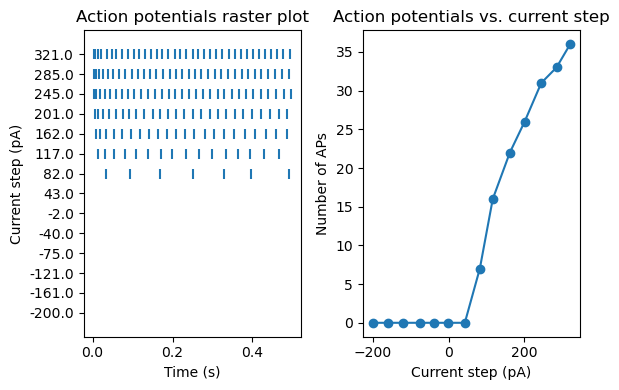

In [18]:
def detect_aps(v):
    ap_peak_times = []
    ap_peak_amps = []
    ap_waveforms = []
    ap_counts = []
    num_trials = v.shape[1]
    ap_win_start = int(0.0005 / dt)
    ap_win_stop = int(0.003 / dt)
    ap_window = np.arange(-ap_win_start, ap_win_stop+1)
    for j in range(num_trials):
        curr_v = v[:, j]
        peaks, _ = find_peaks(curr_v, height=0, distance=int(0.001/dt))
        curr_v = np.pad(curr_v, (ap_win_start, ap_win_stop), 
                        mode='constant', constant_values=np.nan)
        ap_peak_times.append(peaks * dt)
        ap_peak_amps.append(curr_v[peaks+ap_win_start])
        ap_counts.append(len(peaks))

        wf = []
        for ind in peaks:
            inds = ap_window + ind + ap_win_start
            wf.append(curr_v[inds])
        ap_waveforms.append(np.array(wf).T)
    return ap_peak_times, ap_peak_amps, ap_waveforms, ap_counts

ap_peak_times, ap_peak_amps, ap_waveforms, ap_counts = detect_aps(v_dur)

# Plot ap counts vs. current step
fig, ax = plt.subplots(1,2,figsize=(6, 4))
# plot event raster of action potentials for each current step
ax[0].eventplot(ap_peak_times, linelengths=0.5, color='tab:blue')
ax[0].set_yticks(np.arange(pulse_vals.size), np.round(pulse_vals))
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Current step (pA)')
ax[0].set_title('Action potentials raster plot')

# Plot number of action potentials vs. current step
ax[1].plot(pulse_vals, ap_counts, 'o-', color='tab:blue')
ax[1].set_xlabel('Current step (pA)')
ax[1].set_ylabel('Number of APs')
ax[1].set_title('Action potentials vs. current step')
fig.tight_layout()

### Action potential properties
This section analyzes the properties of the first action potential (AP) elicited by current injection. The code identifies the first trial in which an AP occurs, extracts the waveform of the first spike, and visualizes its shape. This allows for detailed examination of AP threshold, amplitude, and kinetics at the minimal suprathreshold current.

**Algorithm overview:**
- Find the first trial with at least one detected AP.
- Extract the current step value (`min_i`) and the voltage at spike threshold (`min_v`).
- Retrieve the waveform of the first AP in that trial (`ap_first_wave`).
- Plot the AP waveform aligned to threshold, highlighting the spike threshold.

**Variables calculated:**
- `min_i`: Current step (in pA) at which the first AP occurs.
- `ap_first_wave`: Voltage waveform of the first AP at threshold current.
- `min_v`: Voltage at the spike threshold (start of the AP upstroke).

This analysis provides insight into the cell's excitability and the biophysical properties of its action potentials.


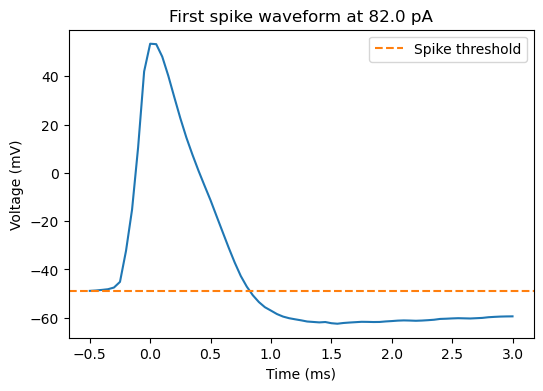

In [19]:
first_spike_trial = [i for i, ap in enumerate(ap_waveforms) if ap.size > 0][0]
min_i = pulse_vals[first_spike_trial]
ap_first_wave = ap_waveforms[first_spike_trial][:,0]
min_v = ap_first_wave[0]

# Plot first spike waveform
ap_win_start = int(0.0005 / dt)
ap_win_stop = int(0.003 / dt)
ap_window = np.arange(-ap_win_start, ap_win_stop+1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ap_window * dt*1000, ap_first_wave, color='tab:blue')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Voltage (mV)')
ax.set_title(f'First spike waveform at {np.round(min_i)} pA')
ax.axhline(min_v, color='tab:orange', linestyle='--', label='Spike threshold')
ax.legend()
plt.show()

### Rebound spiking
In the next code cell, we quantify rebound spiking by detecting action potentials (APs) that occur after the end of the hyperpolarizing current step. They can arise from the $I_h$ current or T-type Calcium current. The algorithm uses the same threshold-based peak detection as for stimulus-evoked spikes, but applies it to the voltage traces during the rebound period (`v_reb`). For each trial, the code counts the number of rebound spikes and prints the results.

**Algorithm overview:**
- Apply the `detect_aps` function to the rebound voltage segment (`v_reb`).
- For each trial, identify AP peaks and count the number of spikes occurring during the rebound phase.
- Summarize the number of rebound spikes across all trials.

**Variables calculated:**
- `reb_counts`: List of the number of rebound spikes detected in each trial. This quantifies the cell's propensity for rebound firing following hyperpolarization.

This analysis helps distinguish cell types based on their rebound spiking behavior (e.g. low-threshold spiking interneurons).

In [20]:
_, _, _, reb_counts = detect_aps(v_reb)
print(f'Number of rebound spikes: {reb_counts}')

Number of rebound spikes: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


### Firing rate and adaptation
This section quantifies the firing rate and spike frequency adaptation of the neuron in response to depolarizing current steps. The code calculates the mean instantaneous firing rate for each trial by measuring the intervals between consecutive action potentials (APs) and taking their inverse. For trials with at least four spikes, it also computes the adaptation ratio, defined as the ratio of the first to the last interspike interval, providing a measure of how much the firing rate slows during a sustained stimulus.

**Algorithm overview:**
- For each trial, compute the instantaneous firing rate as the mean of the inverse interspike intervals (ISIs) if at least two spikes are present.
- Identify the first trial with at least four APs to assess adaptation.
- Calculate the adaptation ratio as the ratio of the first to the last instantaneous firing rate in that trial.

**Variables calculated:**
- `ap_rates`: List of mean firing rates (Hz) for each current step.
- `adaptation_ratio`: Ratio of the first to last instantaneous firing rate in the adaptation trial, quantifying spike frequency adaptation.

Adaptation ratio: 1.61


Text(0.5, 1.0, 'Firing rate vs. current step')

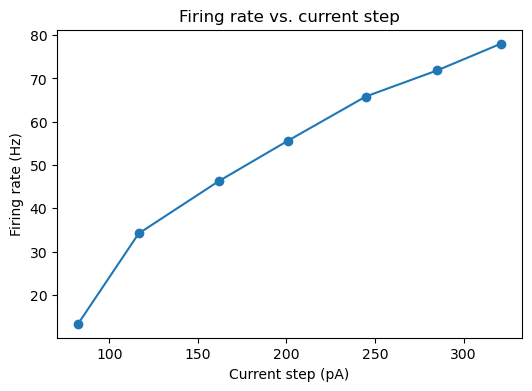

In [11]:
ap_rates = []

# Calculate instantaneous firing rate
for i, times in enumerate(ap_peak_times):
    if len(times) < 2:
        ap_rates.append(np.nan)
        continue
    
    ap_inst_rate = 1/np.diff(times)
    ap_rates.append(np.mean(ap_inst_rate))

# Calculate adaptation ratio
adapt_trial = [i for i, r in enumerate(ap_peak_times) if len(r) >= 4][0]
if adapt_trial is None:
    adaptation_ratio = np.nan
else:
    ap_inst_rate = 1/np.diff(ap_peak_times[adapt_trial])
    adaptation_ratio = ap_inst_rate[0] / ap_inst_rate[-1]

print(f'Adaptation ratio: {adaptation_ratio:.2f}')
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.plot(pulse_vals, ap_rates, 'o-', color='tab:blue')
ax.set_xlabel('Current step (pA)')
ax.set_ylabel('Firing rate (Hz)')
ax.set_title('Firing rate vs. current step')


### Action potential shape
This section quantifies the shape of the action potential (AP) by measuring two key features from the mean AP waveform at threshold current. First is the AP half-width, which is the duration at which the AP waveform remains above half its maximal amplitude, providing a measure of spike duration. The other is the AP peak-to-trough time, which is the time from the AP peak to the minimum (trough) following the peak, reflecting repolarization kinetics. We upsampling (interpolating) the spike waveform to increases the temporal resolution, allowing for more precise determination of key features such as the half-max crossing points and the exact timing of the peak and trough. Since the original sampling interval may be too coarse to capture these events accurately, interpolation ensures that measurements of spike duration and repolarization kinetics are not limited by the discrete time steps of the recorded data.

**Algorithm overview:**
1. Interpolate the mean AP waveform for higher temporal resolution.
2. Calculate the voltage halfway between the baseline and the AP peak.
3. Determine the time interval where the AP is above this half-max value (half-width).
4. Identify the time from the AP peak to the minimum following the peak (peak-to-trough).

**Variables calculated:**
- `ap_halfwidth`: Action potential half-width (s), duration above half-max amplitude.
- `ap_peak_to_trough`: Time from AP peak to trough (s), quantifying repolarization speed.

These metrics are important for distinguishing cell types and understanding the biophysical properties of neuronal firing.

In [12]:
t_wave = np.linspace(0.0005, 0.003, ap_first_wave.size)
interp_t = np.arange(0.0005, 0.003, 0.00001)
interp_func = interp1d(t_wave, ap_first_wave, kind='cubic', fill_value='extrapolate')
up_wave = interp_func(interp_t)
v_half = (np.max(up_wave) - up_wave[0]) / 2 + up_wave[0]
ap_halfwidth = np.sum(up_wave > v_half) * 0.00001
peak_ind = np.argmax(up_wave)
ap_peak_to_trough = np.argmin(up_wave[peak_ind:]) * 0.00001

print(f'Action potential half-width: {1000*ap_halfwidth:.2f} ms')
print(f'Action potential peak-to-trough: {1000*ap_peak_to_trough:.2f} ms')

Action potential half-width: 0.36 ms
Action potential peak-to-trough: 1.09 ms


### Passive membrane properties
This section quantifies the passive membrane properties of the neuron, which are essential for understanding its intrinsic electrical characteristics. The code in the next cell calculates the steady-state membrane potential in response to negative current steps, and uses these responses to estimate the membrane resistance and time constant.

**Algorithm overview:**
- The steady-state voltage (`mem_v`) is measured at the end of each current step, providing a readout of the cell's response to sustained current injection.
- The code selects a small, negative current step (second to last negative pulse) to avoid activating voltage-dependent conductances.
- Membrane resistance (`mem_r`) is calculated as the slope of the voltage change over the current change (ΔV/ΔI) for negative current steps, reflecting how much the membrane potential changes in response to injected current.
- The membrane time constant (`mem_t`) is estimated by fitting an exponential function to the voltage response during the selected negative pulse, quantifying how quickly the membrane potential approaches its new steady state after a current step.

**Variables calculated:**
- `mem_v`: Median steady-state membrane potential at the end of each current step (mV).
- `mem_r`: Membrane resistance (MΩ), calculated from the voltage response to negative current steps.
- `mem_t`: Membrane time constant (s), estimated from exponential fit to the voltage relaxation.

Membrane resistance: 161.13 MOhms
Membrane time constant: 7.52 ms


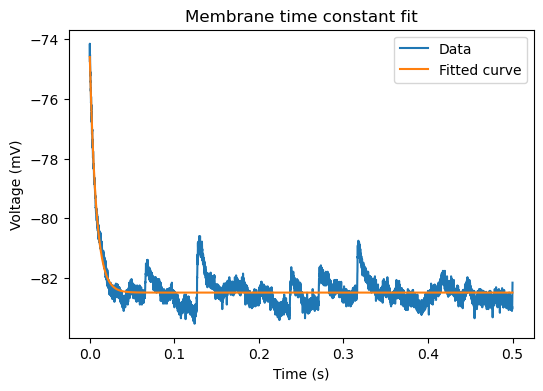

In [13]:
asymp_ind = int(0.1 / dt)
mem_v = np.median(v_dur[-asymp_ind:, :], axis=0)

# Select the second to last negative pulse for resistance and time constant calculations
sel_neg_pulse = np.where(pulse_vals < 0)[0][-2]

# Calculate membrane resistance as the slope of the voltage change
# over the current change during negative current injections
dv = np.diff(mem_v[(sel_neg_pulse-2):(sel_neg_pulse+2)]) * 0.001  # V
di = np.diff(pulse_vals[(sel_neg_pulse-2):(sel_neg_pulse+2)]) * 1e-12     # A
mem_r = np.mean(dv / di) # Ohms

# Calculate membrane time constant in response to a small negative current step
# fit an exponential decay to the second to last negative pulse, capacitance is C = tau / R
v_fit = v_dur[:, sel_neg_pulse]
t_fit = np.arange(0, v_fit.size * dt, dt)

# tau is the time constant, a is the amplitude, b is the offset
fit_func = lambda t, tau, a, b: (a*(1-np.exp(-t / tau)))+b
p0 = [0.01, # 10 ms time constant
        pulse_vals[sel_neg_pulse]*mem_r*1e-9, # expected amplitude in mV
        v_fit[0]] # initial voltage
bounds = ([0, -np.inf, -200], [1, 0, 0])
popt, _ = curve_fit(fit_func, t_fit, v_fit, p0=p0, bounds=bounds)
tau = popt[0]
mem_t = tau  # Time constant in seconds

print(f'Membrane resistance: {(1e-6*mem_r):.2f} MOhms')
print(f'Membrane time constant: {1000*mem_t:.2f} ms')

# Plot the fitted exponential decay
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_fit, v_fit, label='Data', color='tab:blue')
ax.plot(t_fit, fit_func(t_fit, *popt), '-', label='Fitted curve', color='tab:orange')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Voltage (mV)')
ax.set_title('Membrane time constant fit')
ax.legend()
plt.show()

### Sag
A characteristic upward "sag" in the voltage response during a hyperpolarizing current step. This sag is due to the activation of $I_h$ channels, which depolarize the membrane in response to strong hyperpolarization.

The code in the next cell quantifies the sag by measuring the minimum voltage (most hyperpolarized point) and the steady-state voltage at the end of the current step for the most negative current injection. The sag amplitude is the difference between these two values, and the sag ratio is the steady-state voltage divided by the minimum voltage. These metrics help characterize the presence and strength of $I_h$ currents in the neuron.

**Algorithm overview:**
- Select the trial with the most negative current step.
- Subtract the initial voltage to normalize the response.
- Find the minimum voltage during the early part of the step (sag).
- Calculate the median voltage at the end of the step (steady-state).
- Compute the sag amplitude and sag ratio.

**Variables calculated:**
- `sag_amp`: Sag amplitude (mV), the difference between the minimum and steady-state voltages.
- `sag_ratio`: Sag ratio (unitless), the steady-state voltage divided by the minimum voltage. A value near 1 indicates no sag, while one approaching 0 suggests a strong sag.

In [14]:
asymp_ind = int(0.1 / dt)
sag_ind = int(0.1 / dt)
neg_trial = np.argmin(pulse_vals)

v_resp = v_dur[:, neg_trial] - v_dur[0, neg_trial]  # subtract resting potential
v_sag = np.min(v_resp[0:sag_ind])
v_asymp = np.median(v_resp[-asymp_ind:])
sag_amp = v_sag - v_asymp
sag_ratio = v_asymp / v_sag

print(f'Sag amplitude: {sag_amp:.2f} mV')
print(f'Sag ratio: {sag_ratio:.2f}')

Sag amplitude: -4.24 mV
Sag ratio: 0.85


## Putting it all together
The `extract_iv_properties` function in `mimo_pack.analyze.invitro` applies all these analyses. It returns a dictionary of the results, which can be used to build a table of electrophysiological properties for all the neurons recorded from in an experiment.

In [15]:
cell_props = extract_iv_properties(data)

print(f'Cell properties: {cell_props}')

Cell properties: {'stim_start_s': 0, 'stim_stop_s': 0.49995000000000006, 'pulse_dur_s': 0.49995000000000006, 'current_baselines_pA': array([-1.2207, -1.2207, -1.2207, ...,  1.8311,  1.8311,  1.8311],
      shape=(14,)), 'current_steps_pA': array([-200.1953, -160.5225, -120.8496, ...,  244.751 ,  285.0342,
        321.0449], shape=(14,)), 'rest_vm_mV': array([-71.9604, -71.6858, -73.5474, ..., -76.8433, -77.3926, -77.5452],
      shape=(14,)), 'rest_vm_mean_mV': np.float64(-74.95553152901786), 'rest_vm_sd_mV': np.float64(1.832691620710829), 'ap_peak_times_s': [array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64), array([0.0329, 0.0926, 0.1698, ..., 0.3298, 0.3956, 0.492 ], shape=(7,)), array([0.0132, 0.0312, 0.0539, ..., 0.3941, 0.4288, 0.4663], shape=(16,)), array([0.008 , 0.0175, 0.0336, ..., 0.4335, 0.4597, 0.486 ], shape=(22,)), array([0.0059, 0.0125, 0.026